In [360]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
from sklearn.model_selection import KFold
from sklearn.metrics import mean_absolute_error

In [361]:
# Data
x_train = pd.read_csv("../data/x_train_final.csv")
y_train = pd.read_csv("../data/y_train_final.csv")
x_test = pd.read_csv("../data/x_test_final.csv")

In [362]:
x_train

,Unnamed: 0.1,Unnamed: 0,train,gare,date,arret,p2q0,p3q0,p4q0,p0q2,p0q3,p0q4
0,0,0,VBXNMF,KYF,2023-04-03,8,0.0,0.0,1.0,-3.0,-1.0,-2.0
1,1,1,VBXNMF,JLR,2023-04-03,9,0.0,0.0,0.0,1.0,0.0,1.0
2,2,2,VBXNMF,EOH,2023-04-03,10,-1.0,0.0,0.0,-1.0,0.0,0.0
3,3,3,VBXNMF,VXY,2023-04-03,11,-1.0,-1.0,0.0,2.0,-2.0,0.0
4,4,4,VBXNMF,OCB,2023-04-03,12,-1.0,-1.0,-1.0,-1.0,3.0,2.0
...,...,...,...,...,...,...,...,...,...,...,...,...
667259,667259,667259,BFNJJK,DGG,2023-11-10,22,0.0,-1.0,-6.0,-1.0,0.0,-2.0
667260,667260,667260,BFNJJK,KDN,2023-11-10,23,0.0,0.0,-1.0,1.0,0.0,0.0
667261,667261,667261,BFNJJK,TVD,2023-11-10,24,1.0,0.0,0.0,-1.0,-3.0,-1.0
667262,667262,667262,BFNJJK,TXP,2023-11-10,26,2.0,2.0,1.0,0.0,0.0,1.0


In [363]:
y_train

,Unnamed: 0,p0q0
0,0,-1.0
1,1,-1.0
2,2,-1.0
3,3,1.0
4,4,3.0
...,...,...
667259,667259,1.0
667260,667260,2.0
667261,667261,2.0
667262,667262,1.0


## Feature Engineering

In [ ]:
def fit_features(train_df: pd.DataFrame) -> dict:
    df = train_df.copy()
    df["date"] = pd.to_datetime(df["date"])

    cols_retard = ["p2q0", "p3q0", "p4q0", "p0q2", "p0q3", "p0q4"]

    mappings = {}

    # fréquence gare (OK)
    mappings["freq_gare"] = df["gare"].value_counts(normalize=True)

    # retard moyen par gare (OK)
    mappings["retard_moyen_gare"] = df.groupby("gare")[cols_retard].mean().mean(axis=1)

    # nombre moyen d'arrêts par train (à apprendre sur le train seulement)
    mappings["nb_arrets_par_train"] = df.groupby("train")["arret"].count()

    # nombre moyen d'arrêts par gare
    mappings["nb_arrets_par_gare"] = df.groupby("gare")["arret"].count()

    return mappings

def transform_features(df: pd.DataFrame, mappings: dict) -> pd.DataFrame:
    df = df.copy()

    # Outliers
    df.loc[df["p0q3"] <= -500, "p0q3"] = (df["p0q2"] + df["p0q4"]) / 2
    df.loc[df["p0q4"] <= -500, "p0q4"] = (df["p0q2"] + df["p0q3"]) / 2

    # Date
    df["date"] = pd.to_datetime(df["date"])
    df["month"] = df["date"].dt.month
    df["day_of_week"] = df["date"].dt.dayofweek

    # Encodage cyclique
    df["month_sin"] = np.sin(2 * np.pi * df["month"] / 12)
    df["month_cos"] = np.cos(2 * np.pi * df["month"] / 12)
    df["day_of_week_sin"] = np.sin(2 * np.pi * df["day_of_week"] / 5)
    df["day_of_week_cos"] = np.cos(2 * np.pi * df["day_of_week"] / 5)

    # Frequency encoding gare
    df["encoded_gare"] = df["gare"].map(mappings["freq_gare"]).fillna(0)

    # Retard moyen par gare
    df["retard_moyen_gare"] = df["gare"].map(mappings["retard_moyen_gare"]).fillna(0)

    # Nombre d'arrêts appris sur le train
    df["nb_arrets_gare"] = df["gare"].map(mappings["nb_arrets_par_gare"]).fillna(0)

    # Features retard train
    df["somme_retard_prev_trains"] = df["p2q0"] + df["p3q0"] + df["p4q0"]
    df["diff_retard_trains"] = df["p2q0"] - df["p4q0"]
    df["mean_retard_train"] = df[["p2q0","p3q0","p4q0"]].mean(axis=1)
    df["std_retard_train"] = df[["p2q0","p3q0","p4q0"]].std(axis=1)

    # Features retard gare
    df["somme_retard_prev_gares"] = df["p0q2"] + df["p0q3"] + df["p0q4"]
    df["diff_retard_gares"] = df["p0q2"] - df["p0q4"]
    df["mean_retard_gare"] = df[["p0q2","p0q3","p0q4"]].mean(axis=1)
    df["std_retard_gare"] = df[["p0q2","p0q3","p0q4"]].std(axis=1)

    # Drop colonnes inutiles
    cols_to_drop = ["Unnamed: 0.1", "Unnamed: 0", "date", "day_of_week", "month", "gare", "train"]
    df = df.drop(columns=[c for c in cols_to_drop if c in df.columns])

    return df

In [365]:
# Fit sur train, transform sur train et test
mappings = fit_features(x_train)
x_train_fe = transform_features(x_train, mappings)
x_test_fe = transform_features(x_test, mappings)

In [366]:
x_train_fe

,arret,p2q0,p3q0,p4q0,p0q2,p0q3,p0q4,month_sin,month_cos,day_of_week_sin,...,nb_arrets_train,nb_arrets_gare,somme_retard_prev_trains,diff_retard_trains,mean_retard_train,std_retard_train,somme_retard_prev_gares,diff_retard_gares,mean_retard_gare,std_retard_gare
0,8,0.0,0.0,1.0,-3.0,-1.0,-2.0,0.866025,-0.500000,0.000000,...,5,29737,1.0,-1.0,0.333333,0.57735,-6.0,-1.0,-2.000000,1.000000
1,9,0.0,0.0,0.0,1.0,0.0,1.0,0.866025,-0.500000,0.000000,...,5,31643,0.0,0.0,0.000000,0.00000,2.0,0.0,0.666667,0.577350
2,10,-1.0,0.0,0.0,-1.0,0.0,0.0,0.866025,-0.500000,0.000000,...,5,26037,-1.0,-1.0,-0.333333,0.57735,-1.0,-1.0,-0.333333,0.577350
3,11,-1.0,-1.0,0.0,2.0,-2.0,0.0,0.866025,-0.500000,0.000000,...,5,27842,-2.0,-1.0,-0.666667,0.57735,0.0,2.0,0.000000,2.000000
4,12,-1.0,-1.0,-1.0,-1.0,3.0,2.0,0.866025,-0.500000,0.000000,...,5,29230,-3.0,0.0,-1.000000,0.00000,4.0,-3.0,1.333333,2.081666
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
667259,22,0.0,-1.0,-6.0,-1.0,0.0,-2.0,-0.500000,0.866025,-0.433884,...,19,7663,-7.0,6.0,-2.333333,3.21455,-3.0,1.0,-1.000000,1.000000
667260,23,0.0,0.0,-1.0,1.0,0.0,0.0,-0.500000,0.866025,-0.433884,...,19,7758,-1.0,1.0,-0.333333,0.57735,1.0,1.0,0.333333,0.577350
667261,24,1.0,0.0,0.0,-1.0,-3.0,-1.0,-0.500000,0.866025,-0.433884,...,19,9333,1.0,1.0,0.333333,0.57735,-5.0,0.0,-1.666667,1.154701
667262,26,2.0,2.0,1.0,0.0,0.0,1.0,-0.500000,0.866025,-0.433884,...,19,853,5.0,1.0,1.666667,0.57735,1.0,-1.0,0.333333,0.577350


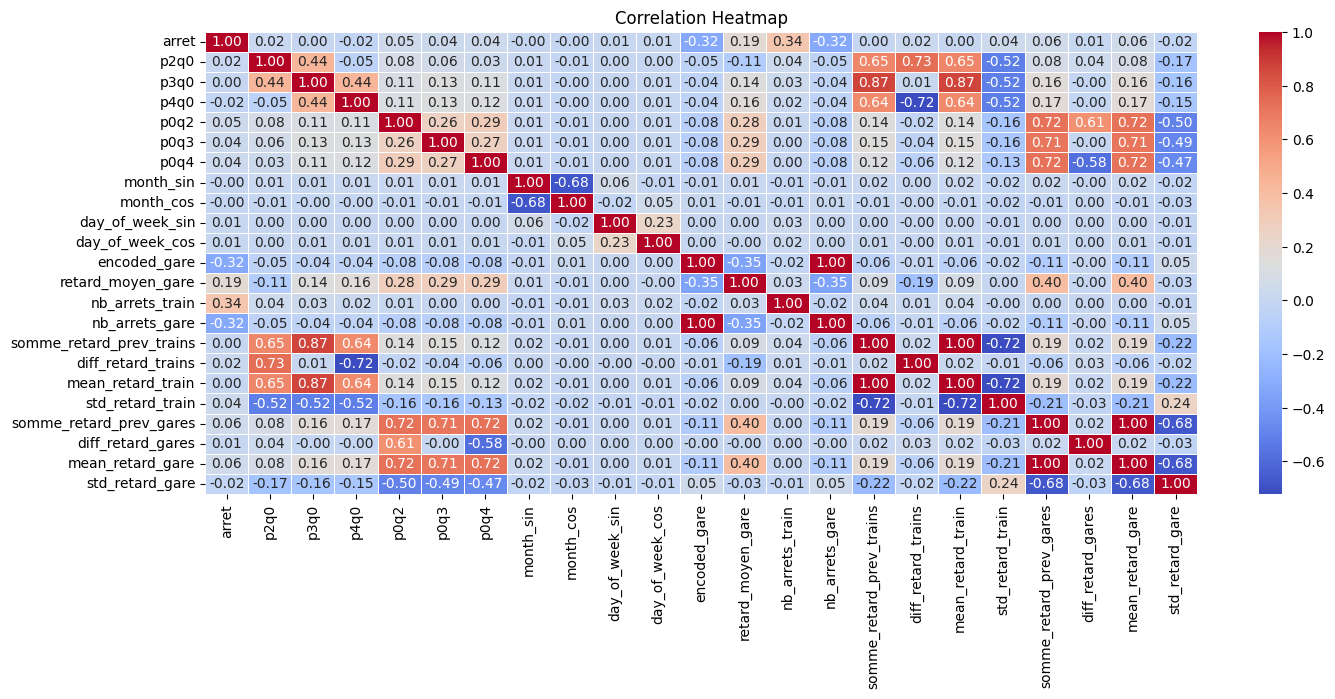

In [367]:
matrix = x_train_fe.corr()
plt.figure(figsize=(16,6))
sns.heatmap(matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap")
plt.show()

In [368]:
x_test_fe

,arret,p2q0,p3q0,p4q0,p0q2,p0q3,p0q4,month_sin,month_cos,day_of_week_sin,...,nb_arrets_train,nb_arrets_gare,somme_retard_prev_trains,diff_retard_trains,mean_retard_train,std_retard_train,somme_retard_prev_gares,diff_retard_gares,mean_retard_gare,std_retard_gare
0,12,0.0,0.0,-2.0,-4.0,-2.0,-4.0,-5.000000e-01,0.866025,0.000000,...,0.0,27842,-2.0,2.0,-0.666667,1.154701,-10.0,0.0,-3.333333,1.154701
1,12,0.0,0.0,-1.0,1.0,-1.0,0.0,-5.000000e-01,0.866025,0.000000,...,0.0,27842,-1.0,1.0,-0.333333,0.577350,0.0,1.0,0.000000,1.000000
2,12,0.0,1.0,-1.0,1.0,-1.0,1.0,-5.000000e-01,0.866025,0.000000,...,0.0,27842,0.0,1.0,0.000000,1.000000,1.0,0.0,0.333333,1.154701
3,12,0.0,0.0,-1.0,-1.0,0.0,-1.0,-5.000000e-01,0.866025,0.000000,...,0.0,27842,-1.0,1.0,-0.333333,0.577350,-2.0,0.0,-0.666667,0.577350
4,12,1.0,-2.0,0.0,0.0,0.0,0.0,-5.000000e-01,0.866025,0.000000,...,0.0,12286,-1.0,1.0,-0.333333,1.527525,0.0,0.0,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20652,24,-1.0,-1.0,1.0,0.0,1.0,0.0,-2.449294e-16,1.000000,-0.433884,...,0.0,17175,-1.0,-2.0,-0.333333,1.154701,1.0,0.0,0.333333,0.577350
20653,12,0.0,0.0,0.0,0.0,0.0,0.0,-2.449294e-16,1.000000,-0.433884,...,0.0,8471,0.0,0.0,0.000000,0.000000,0.0,0.0,0.000000,0.000000
20654,18,1.0,-2.0,0.0,-1.0,-1.0,-2.0,-2.449294e-16,1.000000,-0.433884,...,0.0,21449,-1.0,1.0,-0.333333,1.527525,-4.0,1.0,-1.333333,0.577350
20655,24,-2.0,-2.0,1.0,0.0,0.0,1.0,-2.449294e-16,1.000000,-0.433884,...,0.0,17175,-3.0,-3.0,-1.000000,1.732051,1.0,-1.0,0.333333,0.577350


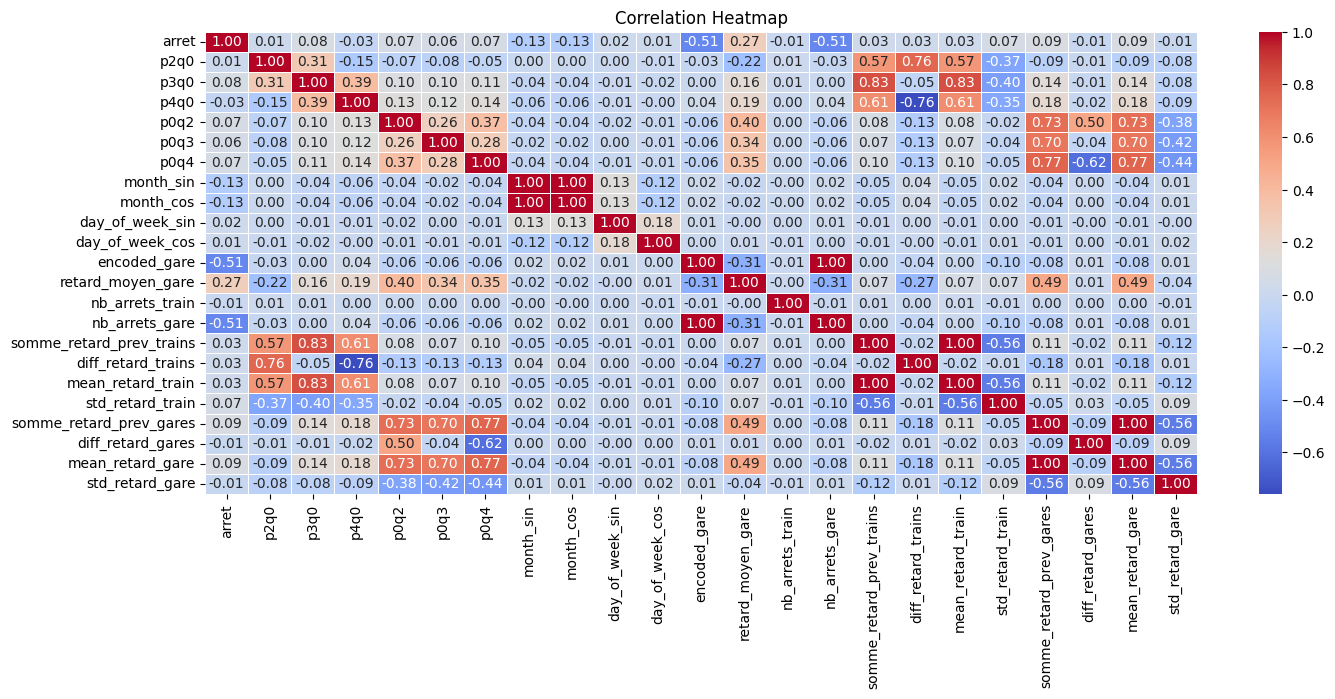

In [369]:
matrix = x_test_fe.corr()
plt.figure(figsize=(16,6))
sns.heatmap(matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap")
plt.show()

## Modeles

# KFold

In [370]:
import lightgbm as lgb

SEED = 42

kf = KFold(n_splits=5, shuffle=False)

oof_preds = np.zeros(len(x_train_fe))
test_preds = np.zeros(len(x_test_fe))
fold_scores = []

X = x_train_fe
X_test = x_test_fe
y = y_train.drop(columns=["Unnamed: 0"])["p0q0"]

# Paramètres LightGBM
lgb_params = {
    "n_estimators": 5000,
    "learning_rate": 0.01,
    "max_depth": -1,
    "num_leaves": 64,
    "subsample": 0.8,
    "colsample_bytree": 0.8,
    "random_state": SEED,
    "n_jobs": -1,
    
}

print(f"Entraînement en {kf.n_splits} folds...")
print("─" * 60)

for fold, (train_idx, val_idx) in enumerate(kf.split(X, y), 1):
    X_tr, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_tr, y_val = y.iloc[train_idx], y.iloc[val_idx]

    model = lgb.LGBMRegressor(**lgb_params)

    model.fit(
        X_tr, y_tr,
        eval_set=[(X_val, y_val)],
        eval_metric="mae",
        callbacks=[lgb.early_stopping(200), lgb.log_evaluation(0)],
        
    )

    val_pred = model.predict(X_val)
    oof_preds[val_idx] = val_pred
    test_preds += model.predict(X_test) / kf.n_splits

    score = mean_absolute_error(y_val, val_pred)
    fold_scores.append(score)
    print(f"  Fold {fold} | MAE = {score:.4f}")

print("─" * 60)
oof_score = mean_absolute_error(y, oof_preds)
print(f"  OOF global        | MAE = {oof_score:.4f}")
print(f"  Moyenne des folds | MAE = {np.mean(fold_scores):.4f} ± {np.std(fold_scores):.4f}")

Entraînement en 5 folds...
────────────────────────────────────────────────────────────
Training until validation scores don't improve for 200 rounds
Early stopping, best iteration is:
[503]	valid_0's l1: 0.6678	valid_0's l2: 1.68924
  Fold 1 | MAE = 0.6678
Training until validation scores don't improve for 200 rounds
Early stopping, best iteration is:
[429]	valid_0's l1: 0.747453	valid_0's l2: 2.25209
  Fold 2 | MAE = 0.7475
Training until validation scores don't improve for 200 rounds


KeyboardInterrupt: 

# GroupKFold

In [371]:
import lightgbm as lgb
from sklearn.model_selection import GroupKFold

SEED = 42

gkf = GroupKFold(n_splits=5)

oof_preds = np.zeros(len(x_train_fe))
test_preds = np.zeros(len(x_test_fe))
fold_scores = []

X = x_train_fe
X_test = x_test_fe
y = y_train.drop(columns=["Unnamed: 0"])["p0q0"]

groupes = x_train["train"]

# Paramètres LightGBM
lgb_params = {
    "n_estimators": 5000,
    "learning_rate": 0.01,
    "max_depth": -1,
    "num_leaves": 64,
    "subsample": 0.8,
    "colsample_bytree": 0.8,
    "random_state": SEED,
    "n_jobs": -1,
    
}

print(f"Entraînement en {gkf.n_splits} folds...")
print("─" * 60)

for train_idx, val_idx in gkf.split(X, y, groupes):
    X_tr, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_tr, y_val = y.iloc[train_idx], y.iloc[val_idx]

    model = lgb.LGBMRegressor(**lgb_params)

    model.fit(
        X_tr, y_tr,
        eval_set=[(X_val, y_val)],
        eval_metric="mae",
        callbacks=[lgb.early_stopping(200), lgb.log_evaluation(0)],
        
    )

    val_pred = model.predict(X_val)
    oof_preds[val_idx] = val_pred
    test_preds += model.predict(X_test) / kf.n_splits

    score = mean_absolute_error(y_val, val_pred)
    fold_scores.append(score)
    print(f"  Fold {fold} | MAE = {score:.4f}")

print("─" * 60)
oof_score = mean_absolute_error(y, oof_preds)
print(f"  OOF global        | MAE = {oof_score:.4f}")
print(f"  Moyenne des folds | MAE = {np.mean(fold_scores):.4f} ± {np.std(fold_scores):.4f}")

Entraînement en 5 folds...
────────────────────────────────────────────────────────────
Training until validation scores don't improve for 200 rounds
Early stopping, best iteration is:
[4226]	valid_0's l1: 0.727986	valid_0's l2: 3.37761
  Fold 3 | MAE = 0.7280
Training until validation scores don't improve for 200 rounds
Early stopping, best iteration is:
[1061]	valid_0's l1: 0.742129	valid_0's l2: 2.97698
  Fold 3 | MAE = 0.7421
Training until validation scores don't improve for 200 rounds
Early stopping, best iteration is:
[966]	valid_0's l1: 0.751282	valid_0's l2: 2.91377
  Fold 3 | MAE = 0.7513
Training until validation scores don't improve for 200 rounds
Early stopping, best iteration is:
[764]	valid_0's l1: 0.743244	valid_0's l2: 3.10884
  Fold 3 | MAE = 0.7432
Training until validation scores don't improve for 200 rounds
Early stopping, best iteration is:
[2924]	valid_0's l1: 0.732355	valid_0's l2: 2.84919
  Fold 3 | MAE = 0.7324
─────────────────────────────────────────────────

## TimeSeriesSplit

In [374]:
from sklearn.model_selection import TimeSeriesSplit

# 1. Trier les données par date
print("Tri des données par date...")
# Assurez-vous que la colonne 'date' est au format datetime
x_train['date'] = pd.to_datetime(x_train['date'])
# Obtenir les indices triés
sorted_indices = x_train.sort_values(by='date').index
# Trier x_train et y_train
x_train_sorted = x_train.loc[sorted_indices].reset_index(drop=True)
y_train_sorted = y_train.loc[sorted_indices].reset_index(drop=True)
print("Tri terminé.")

# 2. Appliquer le feature engineering sur les données triées
print("Application du feature engineering...")
mappings = fit_features(x_train_sorted)
x_train_fe_sorted = transform_features(x_train_sorted, mappings)
# Le test set n'a pas besoin d'être trié, on applique juste les mappings appris sur le train
x_test_fe = transform_features(x_test, mappings)
print("Feature engineering terminé.")

# 3. Mettre en place et lancer TimeSeriesSplit
SEED = 42

# Meilleurs paramètres trouvés avec Optuna (ceux de votre notebook)
lgb_params = {
    'learning_rate': 0.021672720518216216,
    'num_leaves': 77,
    'max_depth': 0,
    'min_child_samples': 15,
    'subsample': 0.6391951346908876,
    'colsample_bytree': 0.7303303590395579,
    'reg_alpha': 3.6677557138349606,
    'reg_lambda': 2.621554716462955,
    'n_estimators': 5000,
    'random_state': SEED,
    'n_jobs': -1
}

tscv = TimeSeriesSplit(n_splits=5)

X = x_train_fe_sorted
y = y_train_sorted.drop(columns=["Unnamed: 0"])["p0q0"]

# Initialisation des tableaux pour les prédictions
oof_preds = np.zeros(len(X))
test_preds = np.zeros(len(x_test_fe))
fold_scores = []

print(f"\nEntraînement avec TimeSeriesSplit ({tscv.n_splits} folds)...")
print("─" * 60)

for fold, (train_idx, val_idx) in enumerate(tscv.split(X), 1):
    X_tr, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_tr, y_val = y.iloc[train_idx], y.iloc[val_idx]

    model = lgb.LGBMRegressor(**lgb_params)

    model.fit(
        X_tr, y_tr,
        eval_set=[(X_val, y_val)],
        eval_metric="mae",
        callbacks=[lgb.early_stopping(300), lgb.log_evaluation(0)]
    )

    val_pred = model.predict(X_val)
    oof_preds[val_idx] = val_pred
    test_preds += model.predict(x_test_fe) / tscv.n_splits
    
    score = mean_absolute_error(y_val, val_pred)
    fold_scores.append(score)
    print(f"  Fold {fold} | MAE = {score:.4f}")

print("─" * 60)
# Avec TimeSeriesSplit, les OOF (Out-of-Fold) ne couvrent pas tout le jeu de données,
# car les premiers plis d'entraînement sont plus petits. On se concentre donc sur la moyenne des scores.
print(f"  Moyenne des folds | MAE = {np.mean(fold_scores):.4f} ± {np.std(fold_scores):.4f}")

Tri des données par date...
Tri terminé.
Application du feature engineering...
Feature engineering terminé.

Entraînement avec TimeSeriesSplit (5 folds)...
────────────────────────────────────────────────────────────
Training until validation scores don't improve for 300 rounds
Early stopping, best iteration is:
[237]	valid_0's l1: 0.690069	valid_0's l2: 2.23658
  Fold 1 | MAE = 0.6901
Training until validation scores don't improve for 300 rounds
Early stopping, best iteration is:
[125]	valid_0's l1: 0.951421	valid_0's l2: 3.71346
  Fold 2 | MAE = 0.9514
Training until validation scores don't improve for 300 rounds
Early stopping, best iteration is:
[372]	valid_0's l1: 0.790642	valid_0's l2: 4.93626
  Fold 3 | MAE = 0.7906
Training until validation scores don't improve for 300 rounds
Early stopping, best iteration is:
[211]	valid_0's l1: 0.757943	valid_0's l2: 2.97749
  Fold 4 | MAE = 0.7579
Training until validation scores don't improve for 300 rounds
Early stopping, best iteration is

## Optimisation Optuna

In [ ]:
import optuna
import lightgbm as lgb
import numpy as np
from sklearn.model_selection import GroupKFold
from sklearn.metrics import mean_absolute_error

SEED = 42

X = x_train_fe
y = y_train.drop(columns=["Unnamed: 0"])["p0q0"]
groupes = x_train["train"]

gkf = GroupKFold(n_splits=5)

def objective(trial):

    params = {
        "n_estimators": 5000,
        "learning_rate": trial.suggest_float("learning_rate", 0.005, 0.05),
        "num_leaves": trial.suggest_int("num_leaves", 32, 256),
        "max_depth": trial.suggest_int("max_depth", -1, 12),
        "min_child_samples": trial.suggest_int("min_child_samples", 10, 100),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "reg_alpha": trial.suggest_float("reg_alpha", 0.0, 5.0),
        "reg_lambda": trial.suggest_float("reg_lambda", 0.0, 5.0),
        "random_state": SEED,
        "n_jobs": -1
    }

    fold_scores = []

    for train_idx, val_idx in gkf.split(X, y, groupes):

        X_tr, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_tr, y_val = y.iloc[train_idx], y.iloc[val_idx]

        model = lgb.LGBMRegressor(**params)

        model.fit(
            X_tr, y_tr,
            eval_set=[(X_val, y_val)],
            eval_metric="mae",
            callbacks=[lgb.early_stopping(200), lgb.log_evaluation(0)]
        )

        val_pred = model.predict(X_val)
        score = mean_absolute_error(y_val, val_pred)
        fold_scores.append(score)

    return np.mean(fold_scores)


study = optuna.create_study(direction="minimize")
study.optimize(objective, n_trials=30)

print("Best MAE:", study.best_value)
print("Best params:")
print(study.best_params)

Training until validation scores don't improve for 200 rounds
Early stopping, best iteration is:
[4333]	valid_0's l1: 0.753016	valid_0's l2: 3.39746
Training until validation scores don't improve for 200 rounds
Early stopping, best iteration is:
[2948]	valid_0's l1: 0.755871	valid_0's l2: 2.9945
Training until validation scores don't improve for 200 rounds
Did not meet early stopping. Best iteration is:
[5000]	valid_0's l1: 0.75775	valid_0's l2: 2.93013
Training until validation scores don't improve for 200 rounds
Early stopping, best iteration is:
[1709]	valid_0's l1: 0.765137	valid_0's l2: 3.14524
Training until validation scores don't improve for 200 rounds
Early stopping, best iteration is:
[2877]	valid_0's l1: 0.759887	valid_0's l2: 2.87427
Training until validation scores don't improve for 200 rounds
Early stopping, best iteration is:
[4452]	valid_0's l1: 0.764021	valid_0's l2: 3.40772
Training until validation scores don't improve for 200 rounds
Early stopping, best iteration is

## Ré-entrainement avec paramètres optimaux

In [342]:
SEED = 42

# meilleurs paramètres trouvés avec Optuna
lgb_params = study.best_params
lgb_params["n_estimators"] = 5000
lgb_params["random_state"] = SEED
lgb_params["n_jobs"] = -1

groupes = x_train["train"]
gkf = GroupKFold(n_splits=5)

X = x_train_fe
y = y_train.drop(columns=["Unnamed: 0"])["p0q0"]

oof_preds = np.zeros(len(X))
test_preds = np.zeros(len(X_test))

for train_idx, val_idx in gkf.split(X, y, groupes):

    X_tr, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_tr, y_val = y.iloc[train_idx], y.iloc[val_idx]

    model = lgb.LGBMRegressor(**lgb_params)

    model.fit(
        X_tr, y_tr,
        eval_set=[(X_val, y_val)],
        eval_metric="mae",
        callbacks=[lgb.early_stopping(200), lgb.log_evaluation(0)]
    )

    # OOF
    val_pred = model.predict(X_val)
    oof_preds[val_idx] = val_pred

    # TEST
    test_preds += model.predict(X_test) / gkf.n_splits


print('─' * 60)
oof_score = mean_absolute_error(y, oof_preds)

print(f"MAE : {oof_score}")

Training until validation scores don't improve for 200 rounds
Early stopping, best iteration is:
[3118]	valid_0's l1: 0.719911	valid_0's l2: 3.32324
Training until validation scores don't improve for 200 rounds
Early stopping, best iteration is:
[1436]	valid_0's l1: 0.722844	valid_0's l2: 2.94537
Training until validation scores don't improve for 200 rounds
Early stopping, best iteration is:
[2978]	valid_0's l1: 0.724372	valid_0's l2: 2.8394
Training until validation scores don't improve for 200 rounds
Early stopping, best iteration is:
[1951]	valid_0's l1: 0.717151	valid_0's l2: 3.07249
Training until validation scores don't improve for 200 rounds
Early stopping, best iteration is:
[2716]	valid_0's l1: 0.719261	valid_0's l2: 2.8126
────────────────────────────────────────────────────────────
MAE : 0.7207077819453398


In [373]:
# arrondir les prédictions
test_preds = np.round(test_preds)

# soumission
submission = pd.DataFrame({
    'p0q0': test_preds
}, index=x_test.index)


oof_str = f"{oof_score:.4f}"

filename = f"../output/y_test_predictions_MAE_{oof_str}.csv"


print(f'Nombre de prédictions : {len(submission)}')
print(f'Valeurs manquantes    : {submission.isnull().sum().sum()}')
print(f'Min prédit            : {submission["p0q0"].min():.4f}')
print(f'Max prédit            : {submission["p0q0"].max():.4f}')
print(f'Moyenne prédite       : {submission["p0q0"].mean():.4f}')


submission.to_csv(filename)

print(f'\nFichier sauvegardé : {filename} ✓')
display(submission.head(10))

Nombre de prédictions : 20657
Valeurs manquantes    : 0
Min prédit            : -17.0000
Max prédit            : 2.0000
Moyenne prédite       : -0.6420

Fichier sauvegardé : ../output/y_test_predictions_MAE_0.7394.csv ✓


,p0q0
0,-3.0
1,-1.0
2,-1.0
3,-1.0
4,-1.0
5,-1.0
6,-1.0
7,-0.0
8,-0.0
9,-2.0
